In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pprint import pprint
from scipy import stats
from functools import reduce
#import dash_bio
import pyarrow
import biomart
import seaborn as sns
import math
from scipy.stats import linregress

#import dask
#import dask.dataframe as dd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#import plotly.express as px

#import dash_bio

# PCA that can handle missing values
#from pyppca import ppca

# save as pdf
#import kaleido
import os

from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

from tqdm import tqdm

%matplotlib inline
pd.set_option('display.max_columns', None)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

In [2]:
# Change the file name below to your input file name
input_file_name = 'diann_phospho_report.phosphosites_90.tsv'

In [3]:
df = pd.read_csv(input_file_name, sep='\t')
df.columns

Index(['Protein', 'Protein.Names', 'Gene.Names', 'Residue', 'Site', 'Sequence',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia',
       '/scicore/home/heimm/GROUP/Fredrik/pro

In [4]:
df[~df['Protein.Names'].str.endswith('HUMAN')]

,Protein,Protein.Names,Gene.Names,Residue,Site,Sequence,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredri

In [5]:
df.tail()

,Protein,Protein.Names,Gene.Names,Residue,Site,Sequence,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredri

In [6]:
df = df[~df['Gene.Names'].isna()]

In [7]:
df['site_id'] = df['Gene.Names'].str.cat(df['Residue'].str.cat(df['Site'].astype(str)), sep='_')
df.head()

,Protein,Protein.Names,Gene.Names,Residue,Site,Sequence,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredri

In [8]:
df.isna().sum()

Protein                                                                                                               0
Protein.Names                                                                                                         0
Gene.Names                                                                                                            0
Residue                                                                                                               0
Site                                                                                                                  0
                                                                                                                     ..
/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/011_BR-LF-3P_PO4_C21.raw.dia    0
/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/087_BR-LF-3P_PO4_C21.raw.dia    0
/scicore/home/heimm/GROUP/Fredrik/projec

In [9]:
df_ = df.copy()
df_.index = df_.site_id

In [10]:
df_ = df_.drop(['Protein', 'Protein.Names', 'Gene.Names', 'Residue', 'Site', 'Sequence', 'site_id'], axis=1)
df_.head()

,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/016_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/061_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/057_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/002_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/037_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/090_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/066_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/025_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/055_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/054_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/068_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/006_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/013_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/028_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/038_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/046_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/033_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/023_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/074_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/078_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/026_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/053_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/029_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/081_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/007_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/076_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/071r_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/049_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/050_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/051_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/069_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/012_BR-LF-3P_PO4_C21.raw.dia,/scicore/home/heimm/GROUP/Fredrik/projects/Marie_Anne/ma_biovsres_feb2023/phospho/raw/0

In [11]:
df_.columns = df_.columns.str.split('/').str[-1].str.split('.').str[0]
df_.head()

,016_BR-LF-3P_PO4_C21,061_BR-LF-3P_PO4_C21,057_BR-LF-3P_PO4_C21,002_BR-LF-3P_PO4_C21,037_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,066_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,068r_BR-LF-3P_PO4_C21,055_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,068_BR-LF-3P_PO4_C21,006_BR-LF-3P_PO4_C21,013_BR-LF-3P_PO4_C21,028_BR-LF-3P_PO4_C21,038_BR-LF-3P_PO4_C21,046_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,023_BR-LF-3P_PO4_C21,074_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,026_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,029_BR-LF-3P_PO4_C21,081_BR-LF-3P_PO4_C21,007_BR-LF-3P_PO4_C21,071_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,071r_BR-LF-3P_PO4_C21,049_BR-LF-3P_PO4_C21,050_BR-LF-3P_PO4_C21,051_BR-LF-3P_PO4_C21,069_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,015_BR-LF-3P_PO4_C21,027_BR-LF-3P_PO4_C21,019_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,084_BR-LF-3P_PO4_C21,072_BR-LF-3P_PO4_C21,075_BR-LF-3P_PO4_C21,004_BR-LF-3P_PO4_C21,014_BR-LF-3P_PO4_C21,077_BR-LF-3P_PO4_C21,072r_BR-LF-3P_PO4_C21,024_BR-LF-3P_PO4_C21,042_BR-LF-3P_PO4_C21,048_BR-LF-3P_PO4_C21,069r_BR-LF-3P_PO4_C21,018_BR-LF-3P_PO4_C21,031_BR-LF-3P_PO4_C21,085_BR-LF-3P_PO4_C21,035_BR-LF-3P_PO4_C21,052_BR-LF-3P_PO4_C21,059_BR-LF-3P_PO4_C21,030_BR-LF-3P_PO4_C21,056_BR-LF-3P_PO4_C21,073r_BR-LF-3P_PO4_C21,047_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,086_BR-LF-3P_PO4_C21,058_BR-LF-3P_PO4_C21,001_BR-LF-3P_PO4_C21,041_BR-LF-3P_PO4_C21,034_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,022_BR-LF-3P_PO4_C21,020_BR-LF-3P_PO4_C21,080_BR-LF-3P_PO4_C21,063_BR-LF-3P_PO4_C21,021_BR-LF-3P_PO4_C21,011_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,045_BR-LF-3P_PO4_C21,005_BR-LF-3P_PO4_C21
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CCDC187_S478,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,625946.0,260410.0,0,0.0,0.0,0.0,360820.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,220091.0,0.0,0.0,0.0,0.0,0.0,842003.0,0.0,74936.0,0.0
POLGARF_S38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8028.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,96540.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
RAMACL_S36,0.0,0.0,418367.0,0.0,398124.0,0.0,114812.0,0.0,0.0,367695.0,0.0,0,0.00,0.0,0.0,44836.8,52624.5,0.0,0.0,0.0,90785.8,0.0,75648.5,0.0,134365.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,459547.0,0,339765.0,0.0,0.0,278032.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,344537.0,0.0,44466.8,0.0,120320.0,0.0,0.0,187585.0,0.0,0.0,0.0,0.0,327970.0,153032.0,561870.0,0.0,0.0,869804.0,0.0,0.0,0.0,499889.0,73133.7,0.0
SLC12A8_S665,0.0,0.0,0.0,0.0,198425.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
E2F8_T58,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,242857.0,0.0,0.0


In [12]:
df_ = df_.replace(0, np.nan)
df_.head()

,016_BR-LF-3P_PO4_C21,061_BR-LF-3P_PO4_C21,057_BR-LF-3P_PO4_C21,002_BR-LF-3P_PO4_C21,037_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,066_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,068r_BR-LF-3P_PO4_C21,055_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,068_BR-LF-3P_PO4_C21,006_BR-LF-3P_PO4_C21,013_BR-LF-3P_PO4_C21,028_BR-LF-3P_PO4_C21,038_BR-LF-3P_PO4_C21,046_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,023_BR-LF-3P_PO4_C21,074_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,026_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,029_BR-LF-3P_PO4_C21,081_BR-LF-3P_PO4_C21,007_BR-LF-3P_PO4_C21,071_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,071r_BR-LF-3P_PO4_C21,049_BR-LF-3P_PO4_C21,050_BR-LF-3P_PO4_C21,051_BR-LF-3P_PO4_C21,069_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,015_BR-LF-3P_PO4_C21,027_BR-LF-3P_PO4_C21,019_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,084_BR-LF-3P_PO4_C21,072_BR-LF-3P_PO4_C21,075_BR-LF-3P_PO4_C21,004_BR-LF-3P_PO4_C21,014_BR-LF-3P_PO4_C21,077_BR-LF-3P_PO4_C21,072r_BR-LF-3P_PO4_C21,024_BR-LF-3P_PO4_C21,042_BR-LF-3P_PO4_C21,048_BR-LF-3P_PO4_C21,069r_BR-LF-3P_PO4_C21,018_BR-LF-3P_PO4_C21,031_BR-LF-3P_PO4_C21,085_BR-LF-3P_PO4_C21,035_BR-LF-3P_PO4_C21,052_BR-LF-3P_PO4_C21,059_BR-LF-3P_PO4_C21,030_BR-LF-3P_PO4_C21,056_BR-LF-3P_PO4_C21,073r_BR-LF-3P_PO4_C21,047_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,086_BR-LF-3P_PO4_C21,058_BR-LF-3P_PO4_C21,001_BR-LF-3P_PO4_C21,041_BR-LF-3P_PO4_C21,034_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,022_BR-LF-3P_PO4_C21,020_BR-LF-3P_PO4_C21,080_BR-LF-3P_PO4_C21,063_BR-LF-3P_PO4_C21,021_BR-LF-3P_PO4_C21,011_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,045_BR-LF-3P_PO4_C21,005_BR-LF-3P_PO4_C21
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CCDC187_S478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,625946.0,260410.0,NaN,NaN,NaN,NaN,360820.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220091.0,NaN,NaN,NaN,NaN,NaN,842003.0,NaN,74936.0,NaN
POLGARF_S38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8028.36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96540.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAMACL_S36,NaN,NaN,418367.0,NaN,398124.0,NaN,114812.0,NaN,NaN,367695.0,NaN,NaN,NaN,NaN,NaN,44836.8,52624.5,NaN,NaN,NaN,90785.8,NaN,75648.5,NaN,134365.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,459547.0,NaN,339765.0,NaN,NaN,278032.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,344537.0,NaN,44466.8,NaN,120320.0,NaN,NaN,187585.0,NaN,NaN,NaN,NaN,327970.0,153032.0,561870.0,NaN,NaN,869804.0,NaN,NaN,NaN,499889.0,73133.7,NaN
SLC12A8_S665,NaN,NaN,NaN,NaN,198425.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2F8_T58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,242857.0,NaN,NaN


In [13]:
df_log = np.log2(df_)

In [14]:
df_log.index.str.contains(';').sum()

np.int64(0)

In [15]:
df_log.index.isna().sum()

np.int64(0)

In [16]:
df_log.shape

(11444, 75)

In [18]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
phos_cols = ['Biopsy_nt_phospho', 'Biopsy_tu_phospho',
             'Resection_nt_phospho', 'Resection_tu_phospho']
meta = meta.dropna(subset=phos_cols)


# Identified a problematic sample (big outlier by PCA) and decided to remove it from the dataset
#meta = meta[meta['Patient ID'] != 'F']

meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
5,C,BSSE_QGF_145480,BSSE_QGF_145481,BSSE_QGF_182091,BSSE_QGF_182092,001_BR-LF-3_C21,002_BR-LF-3_C21,041_BR-LF-3_C21,042rr_BR-LF-3_C21,001_BR-LF-3P_PO4_C21,002_BR-LF-3P_PO4_C21,041_BR-LF-3P_PO4_C21,042_BR-LF-3P_PO4_C21,83.0,M,6.0,48.0,48.0,467.0,129.0,37.0,12.0,93.0,122.0,4.0,149.0,3.0,4.0,7.0,48.0,83.0,796.0,557.0,26.0,12.0,77.0,86.0,4.0,165.0,120.0,NaN,A,B,multi-nodular,28.0,245.0,164.0,HCC,62.0,91.0,38.0,9.0,92.0,98.0,8.0,0.0,0.0,2.0,0.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,49.0,M,6.0,30.0,29.0,59.0,53.0,38.0,13.0,103.0,161.0,6.0,196.0,1.0,2.0,6.0,25.0,26.0,49.0,56.0,39.0,5.0,115.0,154.0,5.0,209.0,1.0,NaN,NaN,A,1,35.0,11.0,212.0,HCC,99.0,97.0,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0
17,I,BSSE_QGF_182072,BSSE_QGF_182073,BSSE_QGF_182106,BSSE_QGF_182107,024_BR-LF-3_C21,025_BR-LF-3_C21,053_BR-LF-3_C21,054_BR-LF-3_C21,024_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,54.0,F,6.0,35.0,34.0,53.0,92.0,39.0,5.0,91.0,148.0,8.0,142.0,2.0,4.0,6.0,37.0,33.0,44.0,79.0,36.0,6.0,91.0,129.0,6.0,140.0,1.2,NaN,A,A,1,55.0,30.0,157.0,HCC,84.0,94.0,16.0,6.0,75.0,99.0,17.0,1.0,0.0,0.0,8.0,0.0


In [19]:
# Check if we have all phospho-proteome samples in the spectronout output
found = []
for group in phos_cols:
    for seq_id in meta[group]:
        if seq_id in df_log.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)

In [20]:
# Extras
extras = []
for seq_id in df_log.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
df_log_ = df_log.drop(extras, axis=1)

extra: 016_BR-LF-3P_PO4_C21
extra: 037_BR-LF-3P_PO4_C21
extra: 068r_BR-LF-3P_PO4_C21
extra: 055_BR-LF-3P_PO4_C21
extra: 068_BR-LF-3P_PO4_C21
extra: 006_BR-LF-3P_PO4_C21
extra: 038_BR-LF-3P_PO4_C21
extra: 074_BR-LF-3P_PO4_C21
extra: 081_BR-LF-3P_PO4_C21
extra: 007_BR-LF-3P_PO4_C21
extra: 071_BR-LF-3P_PO4_C21
extra: 069_BR-LF-3P_PO4_C21
extra: 015_BR-LF-3P_PO4_C21
extra: 072_BR-LF-3P_PO4_C21
extra: 004_BR-LF-3P_PO4_C21
extra: 069r_BR-LF-3P_PO4_C21
extra: 031_BR-LF-3P_PO4_C21
extra: 030_BR-LF-3P_PO4_C21
extra: 056_BR-LF-3P_PO4_C21
extra: 073r_BR-LF-3P_PO4_C21
extra: 086_BR-LF-3P_PO4_C21
extra: 080_BR-LF-3P_PO4_C21
extra: 005_BR-LF-3P_PO4_C21


In [21]:
meta_phos = meta.loc[:,['Patient ID', 'Biopsy_nt_phospho', 'Biopsy_tu_phospho',
                        'Resection_nt_phospho', 'Resection_tu_phospho',
                        'Age', 'Sex','Time between resection and biopsy',
                        'Total surgery time = ischemia time']].copy()
meta_phos = meta_phos.melt(id_vars=['Patient ID', 'Age', 'Sex',
                                  'Time between resection and biopsy',
                                  'Total surgery time = ischemia time'],
                         value_vars=phos_cols)
meta_phos['Sample_type'] = meta_phos.variable.str.split('_').str[0]
meta_phos['Tissue'] = np.where(meta_phos.variable.str.contains('nt'), 'non-tumor', 'tumor')
meta_phos = meta_phos.drop('variable', axis=1)
meta_phos = meta_phos.rename({'value':'Seq_id', 'Total surgery time = ischemia time': 'Total surgery time',
                           'Patient ID': 'patient_id'}, axis=1)

# biopsy dont have surgery time
meta_phos['Total surgery time'] = np.where(meta_phos['Sample_type'] == 'Biopsy', 0, meta_phos['Total surgery time'])



# Make new column with column names
meta_phos['col_names'] = meta_phos.Tissue.str\
                            .cat(meta_phos.Sample_type.str\
                                .cat(meta_phos.patient_id, sep='_'), sep='_')
meta_phos.index = meta_phos.Seq_id
meta_phos = meta_phos.sort_index()

meta_phos.head()

,patient_id,Age,Sex,Time between resection and biopsy,Total surgery time,Seq_id,Sample_type,Tissue,col_names
Seq_id,,,,,,,,,
001_BR-LF-3P_PO4_C21,C,83,M,245,0.0,001_BR-LF-3P_PO4_C21,Biopsy,non-tumor,non-tumor_Biopsy_C
002_BR-LF-3P_PO4_C21,C,83,M,245,0.0,002_BR-LF-3P_PO4_C21,Biopsy,tumor,tumor_Biopsy_C
011_BR-LF-3P_PO4_C21,D,70,F,29,0.0,011_BR-LF-3P_PO4_C21,Biopsy,non-tumor,non-tumor_Biopsy_D
012_BR-LF-3P_PO4_C21,D,70,F,29,0.0,012_BR-LF-3P_PO4_C21,Biopsy,tumor,tumor_Biopsy_D
013_BR-LF-3P_PO4_C21,N,60,M,15,0.0,013_BR-LF-3P_PO4_C21,Biopsy,non-tumor,non-tumor_Biopsy_N


In [22]:
meta_phos.shape

(52, 9)

In [23]:
new_col_names = {}
for col in df_log_.columns:
    #print(col)
    new_col_names[col] = meta_phos.loc[col,'col_names']
df_log_ = df_log_.rename(new_col_names, axis=1)

In [24]:
df_log_.head()

,tumor_Biopsy_P,non-tumor_Resection_U,tumor_Biopsy_C,tumor_Resection_F,tumor_Resection_P,tumor_Biopsy_I,tumor_Resection_I,non-tumor_Biopsy_N,non-tumor_Biopsy_U,tumor_Resection_J,tumor_Resection_D,tumor_Biopsy_Q,tumor_Biopsy_F,non-tumor_Biopsy_T,non-tumor_Resection_I,tumor_Biopsy_U,tumor_Biopsy_E,non-tumor_Biopsy_L,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Biopsy_D,tumor_Biopsy_T,tumor_Biopsy_J,non-tumor_Resection_D,non-tumor_Resection_L,non-tumor_Biopsy_E,tumor_Biopsy_N,non-tumor_Biopsy_F,tumor_Biopsy_L,non-tumor_Biopsy_I,tumor_Resection_C,tumor_Resection_O,non-tumor_Biopsy_J,tumor_Resection_L,tumor_Resection_N,tumor_Resection_T,non-tumor_Biopsy_P,non-tumor_Resection_O,tumor_Resection_E,tumor_Resection_U,non-tumor_Biopsy_C,non-tumor_Resection_C,non-tumor_Resection_N,non-tumor_Resection_F,non-tumor_Biopsy_Q,non-tumor_Biopsy_O,non-tumor_Resection_P,tumor_Biopsy_O,non-tumor_Biopsy_D,non-tumor_Resection_E,non-tumor_Resection_J
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CCDC187_S478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.255679,17.990425,NaN,NaN,18.460920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.747741,NaN,NaN,NaN,NaN,19.683466,NaN,16.193371
POLGARF_S38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.558842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RAMACL_S36,NaN,18.67441,NaN,NaN,16.808914,NaN,NaN,NaN,NaN,15.683447,NaN,NaN,16.470179,NaN,16.207024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.809853,18.374178,NaN,18.084891,NaN,NaN,NaN,NaN,NaN,18.394299,NaN,15.440441,NaN,17.517185,NaN,NaN,NaN,18.323204,17.223474,19.099877,NaN,NaN,NaN,NaN,NaN,18.931248,16.158249
SLC12A8_S665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2F8_T58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.889748,NaN


In [25]:
phospho_count = {}
for col in df_log_.columns:
    phospho_count[col] = df_log_[col].dropna().shape[0]
    
df_out = pd.DataFrame.from_dict(phospho_count, orient='index').T
df_out.to_csv('phospho_count_IDs.csv')

In [26]:
#fig, ax = plt.subplots(figsize=(8,14))
#sns.barplot(df_out, color='grey', orient='horizontal')

In [27]:
# Too few identifications for patients F, J P

In [28]:
drop = []
for col in df_log_.columns:
    if col.endswith('F') | col.endswith('J') | col.endswith('P'):
        drop.append(col)
        
df_f = df_log_.drop(drop, axis=1)

In [29]:
metadata = meta_phos.loc[:,['Sample_type', 'Sex', 'Age', 'Tissue',
                           'Seq_id', 'patient_id', 'col_names',
                           'Time between resection and biopsy',
                           'Total surgery time']].copy()

metadata = metadata[~metadata.patient_id.isin(['F', 'J', 'P'])]

# Drop patient with long time betwene biopsy and resection
metadata = metadata[metadata.patient_id != 'C']

metadata.index = metadata.Seq_id
metadata_liver = metadata[metadata.Tissue == 'non-tumor'].copy()
metadata_hcc = metadata[metadata.Tissue == 'tumor'].copy()

In [30]:
df_ff = df_f.loc[:,metadata.col_names].copy()

In [31]:
# QC

metadata_qc = metadata.copy()
metadata_qc.index = metadata_qc.col_names

metadata_qc['counts'] = df_ff.shape[0] - df_ff.isna().sum()
metadata_qc.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,counts
col_names,,,,,,,,,,
non-tumor_Biopsy_D,Biopsy,F,70,non-tumor,011_BR-LF-3P_PO4_C21,D,non-tumor_Biopsy_D,29,0.0,2784
tumor_Biopsy_D,Biopsy,F,70,tumor,012_BR-LF-3P_PO4_C21,D,tumor_Biopsy_D,29,0.0,1976
non-tumor_Biopsy_N,Biopsy,M,60,non-tumor,013_BR-LF-3P_PO4_C21,N,non-tumor_Biopsy_N,15,0.0,4540
tumor_Biopsy_N,Biopsy,M,60,tumor,014_BR-LF-3P_PO4_C21,N,tumor_Biopsy_N,15,0.0,3728
non-tumor_Biopsy_O,Biopsy,M,78,non-tumor,020_BR-LF-3P_PO4_C21,O,non-tumor_Biopsy_O,28,0.0,2934


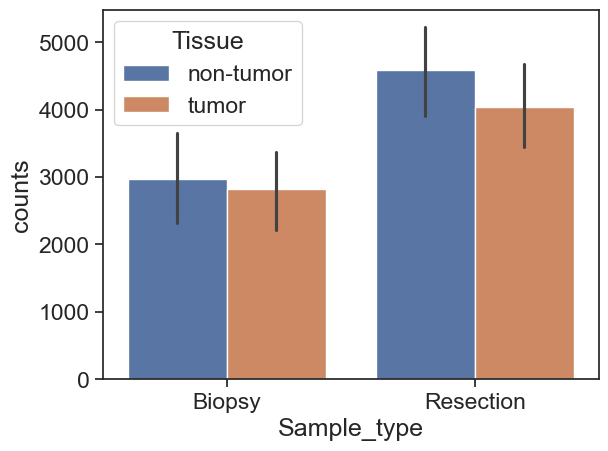

In [32]:
sns.barplot(data=metadata_qc, x='Sample_type', y='counts', hue='Tissue')

plt.savefig('phospho_proteomics_qc_site_ids.pdf', bbox_inches='tight', dpi=300)

In [33]:
res_list = []
for var in metadata_qc.Tissue.unique():
    subset = metadata_qc[metadata_qc.Tissue == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].counts, subset[subset.Sample_type == 'Resection'].counts)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

    
import csv
    
with open('phospho_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

non-tumor
TtestResult(statistic=np.float64(-3.1590804777395225), pvalue=np.float64(0.006078259302837846), df=np.float64(16.0))


tumor
TtestResult(statistic=np.float64(-2.5078454443606044), pvalue=np.float64(0.023303340375574026), df=np.float64(16.0))




In [34]:
df_ff.head()

,non-tumor_Biopsy_D,tumor_Biopsy_D,non-tumor_Biopsy_N,tumor_Biopsy_N,non-tumor_Biopsy_O,tumor_Biopsy_O,non-tumor_Biopsy_Q,tumor_Biopsy_Q,non-tumor_Biopsy_I,tumor_Biopsy_I,non-tumor_Biopsy_T,tumor_Biopsy_T,non-tumor_Biopsy_U,tumor_Biopsy_U,non-tumor_Resection_D,tumor_Resection_D,non-tumor_Resection_N,tumor_Resection_N,non-tumor_Resection_O,tumor_Resection_O,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Resection_T,non-tumor_Resection_I,tumor_Resection_I,non-tumor_Resection_U,tumor_Resection_U,non-tumor_Biopsy_L,tumor_Biopsy_L,non-tumor_Biopsy_E,tumor_Biopsy_E,non-tumor_Resection_L,tumor_Resection_L,non-tumor_Resection_E,tumor_Resection_E
site_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CCDC187_S478,19.683466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.255679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.990425,NaN,NaN,NaN
POLGARF_S38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.558842,NaN,NaN
RAMACL_S36,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.223474,NaN,17.517185,NaN,NaN,NaN,NaN,15.440441,16.207024,NaN,18.67441,NaN,NaN,NaN,18.374178,NaN,18.809853,18.394299,18.931248,NaN
SLC12A8_S665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E2F8_T58,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.889748,NaN


In [35]:
df_ff['Gene'] = df_ff.index.str.split('_').str[0]
df_proteins = df_ff.groupby('Gene').sum()
df_proteins = df_proteins.replace(0, np.nan)
df_proteins.head()

,non-tumor_Biopsy_D,tumor_Biopsy_D,non-tumor_Biopsy_N,tumor_Biopsy_N,non-tumor_Biopsy_O,tumor_Biopsy_O,non-tumor_Biopsy_Q,tumor_Biopsy_Q,non-tumor_Biopsy_I,tumor_Biopsy_I,non-tumor_Biopsy_T,tumor_Biopsy_T,non-tumor_Biopsy_U,tumor_Biopsy_U,non-tumor_Resection_D,tumor_Resection_D,non-tumor_Resection_N,tumor_Resection_N,non-tumor_Resection_O,tumor_Resection_O,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Resection_T,non-tumor_Resection_I,tumor_Resection_I,non-tumor_Resection_U,tumor_Resection_U,non-tumor_Biopsy_L,tumor_Biopsy_L,non-tumor_Biopsy_E,tumor_Biopsy_E,non-tumor_Resection_L,tumor_Resection_L,non-tumor_Resection_E,tumor_Resection_E
Gene,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1CF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.917984,NaN,NaN
AAAS,17.127481,14.981817,17.312387,14.985193,17.844111,16.295349,15.437089,14.893339,NaN,16.921364,18.936569,NaN,16.520597,15.668882,16.240148,16.112323,18.768113,17.869437,18.001908,15.994340,18.448330,15.418495,17.232130,14.857898,15.850795,14.986304,20.837228,15.110630,15.520883,NaN,19.168444,16.251296,17.218270,17.673406,17.714480,17.374216
AAGAB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AAK1,37.935056,38.312138,144.741752,52.969248,76.372144,52.453736,38.467756,84.818231,39.32801,38.067499,54.968373,NaN,17.630957,82.474318,108.833801,91.488209,98.850467,56.249852,121.111467,71.711717,76.142331,55.045871,75.198227,94.836726,91.790148,88.175930,109.042039,37.890331,36.015190,19.013205,117.974019,59.100100,121.188122,116.623225,118.801177,95.356589
AATF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.695690,NaN,16.502000,NaN,NaN,NaN,NaN,14.332687,NaN,NaN,NaN,NaN,NaN,NaN,17.239505,NaN,17.651689,15.485452,17.516470,NaN


In [36]:
metadata_qc['protein_counts'] = df_proteins.shape[0] - df_proteins.isna().sum()

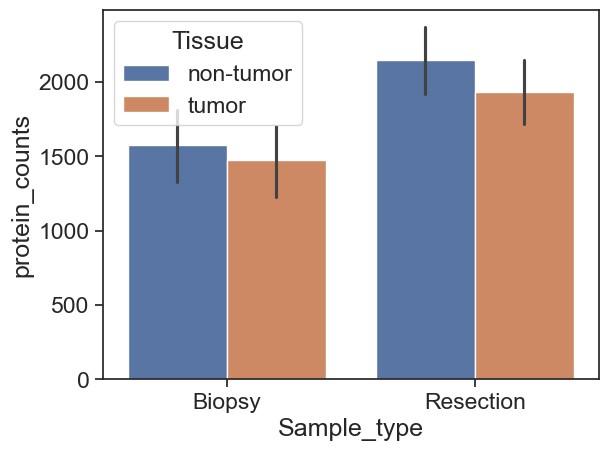

In [37]:
sns.barplot(data=metadata_qc, x='Sample_type', y='protein_counts', hue='Tissue')

plt.savefig('phospho_proteins_qc.pdf', bbox_inches='tight', dpi=300)

In [38]:
res_list = []
for var in metadata_qc.Tissue.unique():
    subset = metadata_qc[metadata_qc.Tissue == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].protein_counts,
                          subset[subset.Sample_type == 'Resection'].protein_counts)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

    
import csv
    
with open('phospho_proteins_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

non-tumor
TtestResult(statistic=np.float64(-3.100363506985184), pvalue=np.float64(0.0068746436283406735), df=np.float64(16.0))


tumor
TtestResult(statistic=np.float64(-2.542324442809296), pvalue=np.float64(0.021737867738058907), df=np.float64(16.0))




In [39]:
df_liver = df_ff.loc[:,metadata_liver.col_names].copy()

df_hcc = df_ff.loc[:,metadata_hcc.col_names].copy()

# Imputation

In [40]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(
    n_neighbors=3,     # small k due to small sample size
    weights='uniform', # or 'distance' if closer samples should weigh more
    metric='nan_euclidean',  # default metric, handles missing values
    add_indicator=True
)
imputer.set_output(transform='pandas')

,missing_values,nan
,n_neighbors,3
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,True
,keep_empty_features,False


In [41]:
# at least 4 valid values
df_liver = df_liver.dropna(thresh=4)
df_hcc = df_hcc.dropna(thresh=4)

In [42]:
df_liver.shape

(5780, 18)

In [43]:
df_hcc.shape

(5054, 18)

In [44]:
df_liver_biop = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Biopsy'].col_names])
df_liver_rese = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Resection'].col_names])

df_hcc_biop = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].col_names])
df_hcc_rese = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Resection'].col_names])

In [45]:
df_liver_imputed = pd.concat([df_liver_biop, df_liver_rese], axis=1)
#df_liver_imputed['Gene'] = df_liver_imputed.index.map(df_liver.Gene)

df_hcc_imputed = pd.concat([df_hcc_biop, df_hcc_rese], axis=1)
#df_hcc_imputed['Gene'] = df_hcc_imputed.index.map(df_hcc.Gene)

In [46]:
# # Histograms of imputed values

# # Create the subplots
# n_rows = math.ceil(len(metadata_liver.col_names)/4)
# fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, len(metadata_liver.col_names)))

# for i, col in enumerate(metadata_liver.col_names):    
#     imp_col = 'missingindicator_' + col
#     sns.histplot(df_liver_imputed, x=col, ax=axes[i//4,i%4],
#                  hue=imp_col, legend=False, bins=20, multiple="stack")
    
#     axes[i//4,i%4].set(xlabel=col + ' (log2)')
    
#     if i == 0 or i%4 == 0:
#         axes[i//4,i%4].set(ylabel='Count')
#     else:
#         axes[i//4,i%4].set(ylabel='')
#     fig.suptitle('Liver')
# #     if len(cols) < 12:
# #         fig.delaxes(axes[i//4,i%4])
# plt.savefig('figures/liver_imputed_values.pdf', bbox_inches='tight')
# #plt.show()
# plt.close()
    

In [47]:
# # HCC
# # Create the subplots
# n_rows = math.ceil(len(metadata_hcc.col_names)/4)
# fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, len(metadata_hcc.col_names)))

# for i, col in enumerate(metadata_hcc.col_names):    
#     imp_col = 'missingindicator_' + col
#     sns.histplot(df_hcc_imputed, x=col, ax=axes[i//4,i%4],
#                  hue=imp_col, legend=False, bins=20, multiple="stack")
    
#     axes[i//4,i%4].set(xlabel=col + ' (log2)')
    
#     if i == 0 or i%4 == 0:
#         axes[i//4,i%4].set(ylabel='Count')
#     else:
#         axes[i//4,i%4].set(ylabel='')
#     fig.suptitle('HCC')
# #     if len(cols) < 12:
# #         fig.delaxes(axes[i//4,i%4])
# plt.savefig('figures/hcc_imputed_values.pdf', bbox_inches='tight')
# #plt.show()
# plt.close()

# PCA

In [48]:
scaler = StandardScaler()
pca = PCA(n_components=2)

In [49]:
hue_order=['Biopsy', 'Resection']

In [50]:
metadata_liver.index = metadata_liver.col_names

metadata_hcc.index = metadata_hcc.col_names

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_16084\49522339.py:54: UserWarning: 
The palette list has fewer values (1) than needed (9) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


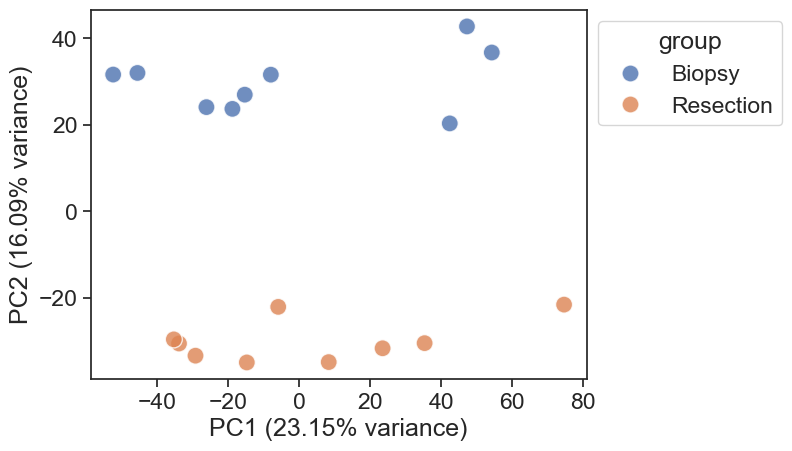

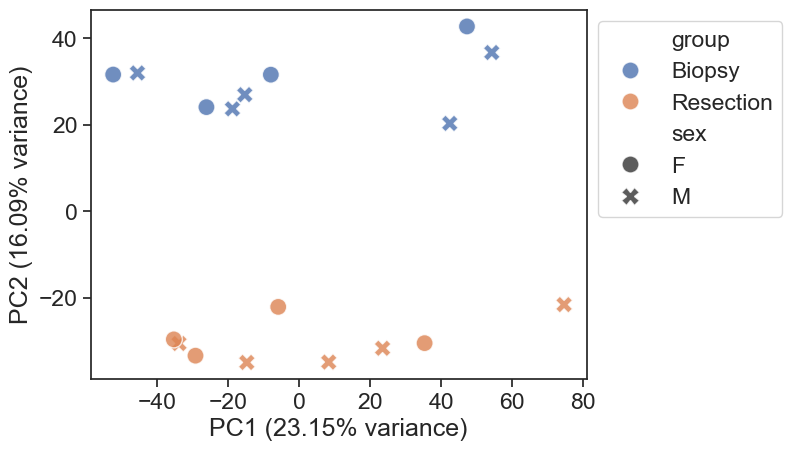

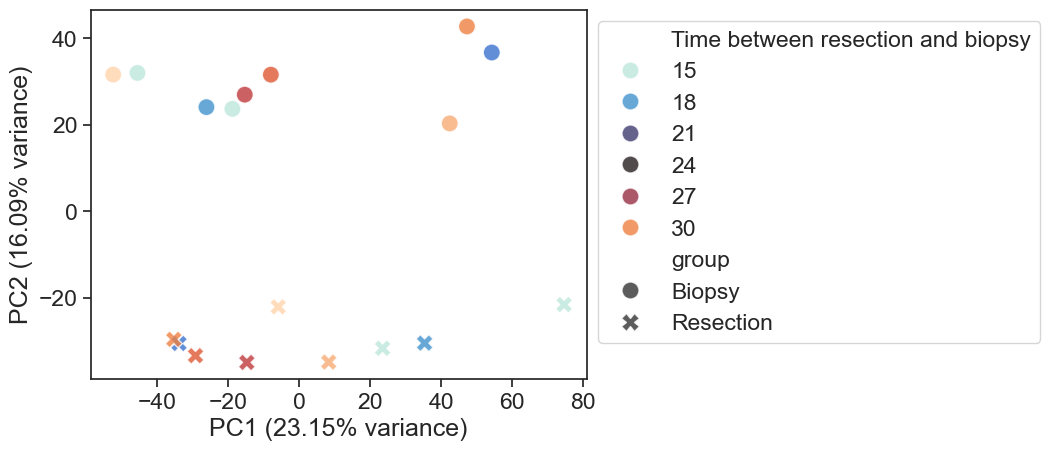

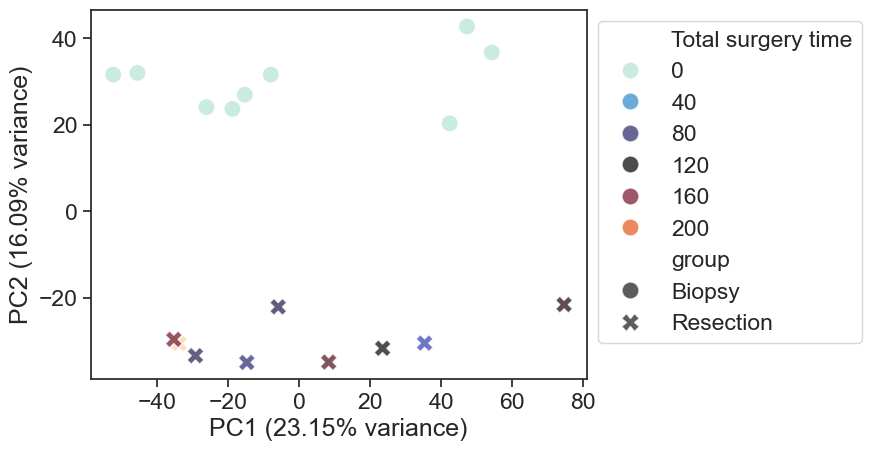

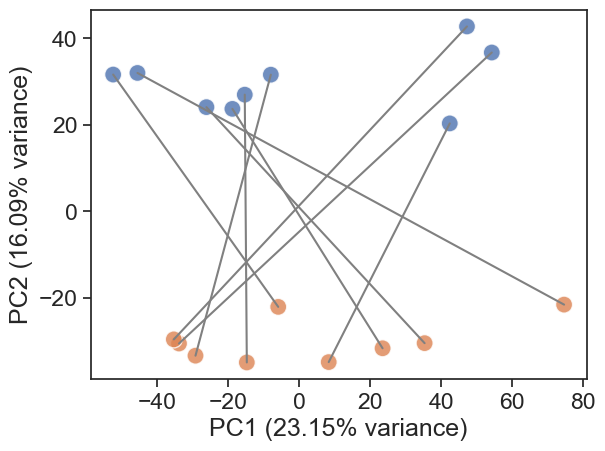

In [51]:
# PCA
used_cols = [x for x in df_liver_imputed.columns if x.startswith('non-tumor')]
scaled = scaler.fit_transform(df_liver_imputed.loc[:,used_cols].T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=['PC1', 'PC2'])
df_pca['group'] = metadata_liver.Sample_type
df_pca['sex'] = metadata_liver.Sex
df_pca['patient_id'] = metadata_liver.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_liver['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_liver['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_sex.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_timeBvR.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_liver_surgerytime.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_liver_pat.pdf', bbox_inches='tight', dpi=300)

In [52]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

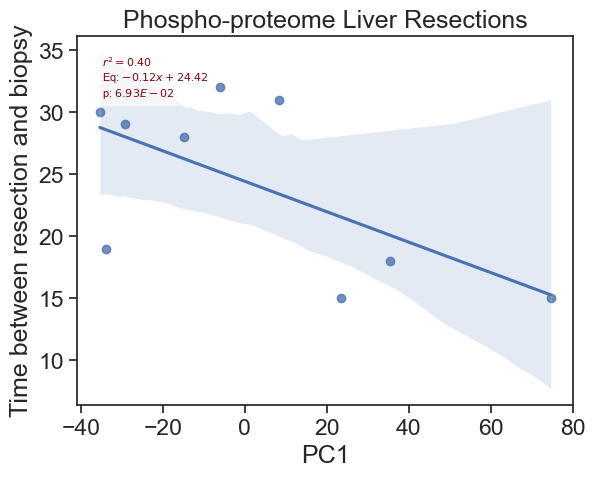

In [53]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Liver Resections')


plt.savefig('figures/corr_pc1_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

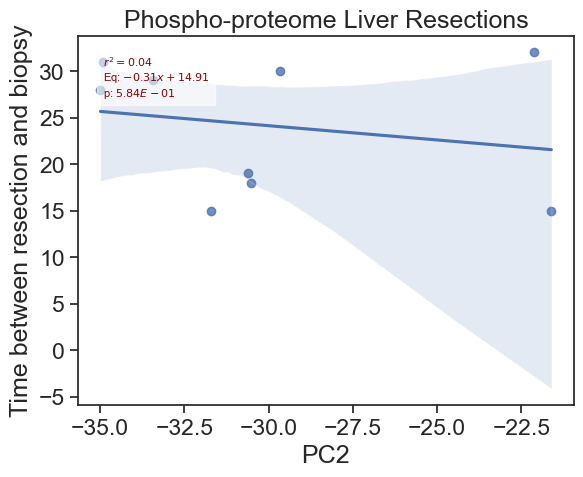

In [54]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Liver Resections')


plt.savefig('figures/corr_pc2_time_b_to_r.pdf', dpi=300, bbox_inches='tight')

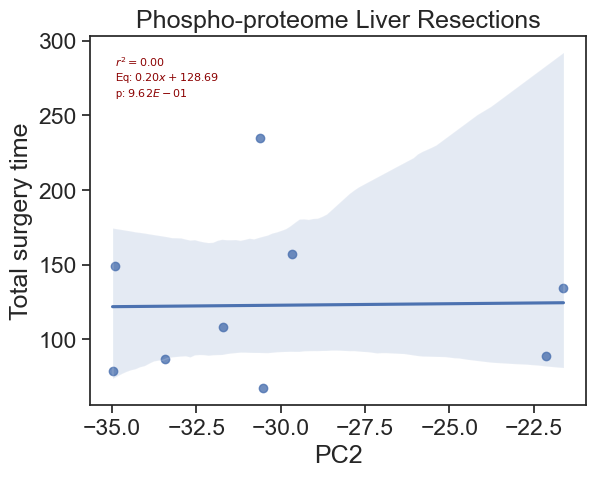

In [55]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Liver Resections')

plt.savefig('figures/corr_pc2_time_surgery.pdf', dpi=300, bbox_inches='tight')

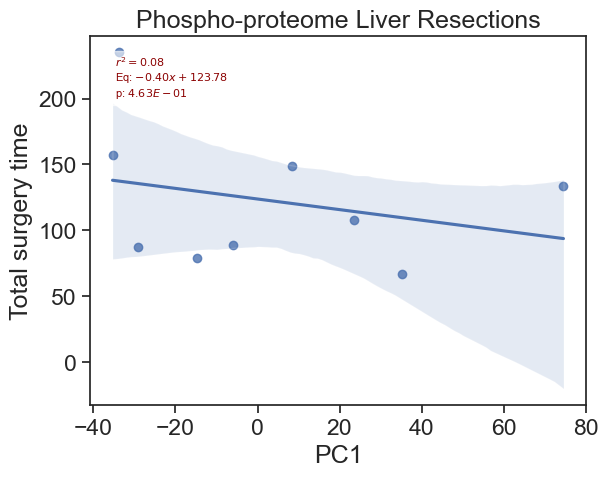

In [56]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Liver Resections')

plt.savefig('figures/corr_pc1_time_surgery.pdf', dpi=300, bbox_inches='tight')

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_16084\1069209739.py:56: UserWarning: 
The palette list has fewer values (1) than needed (9) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


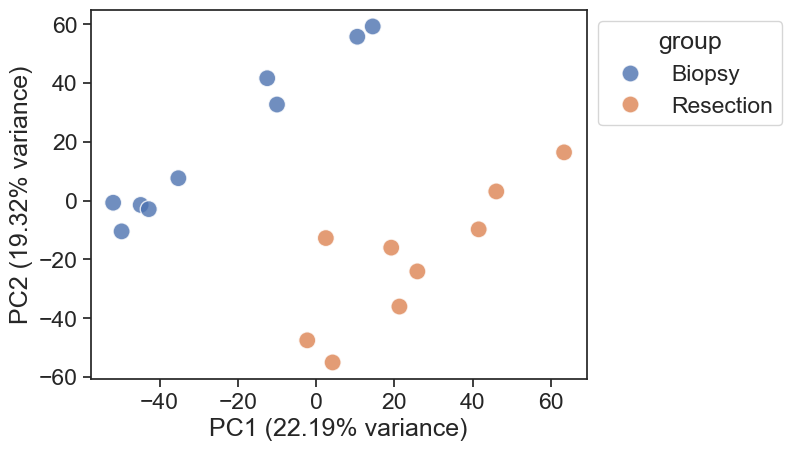

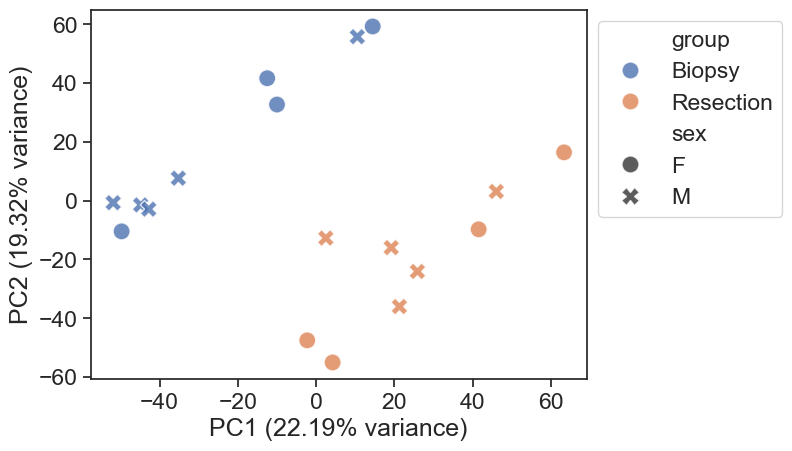

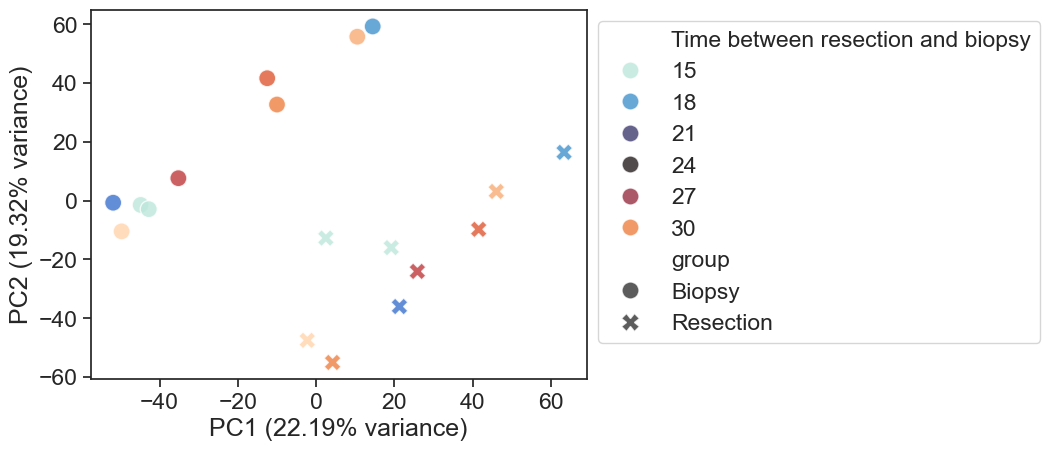

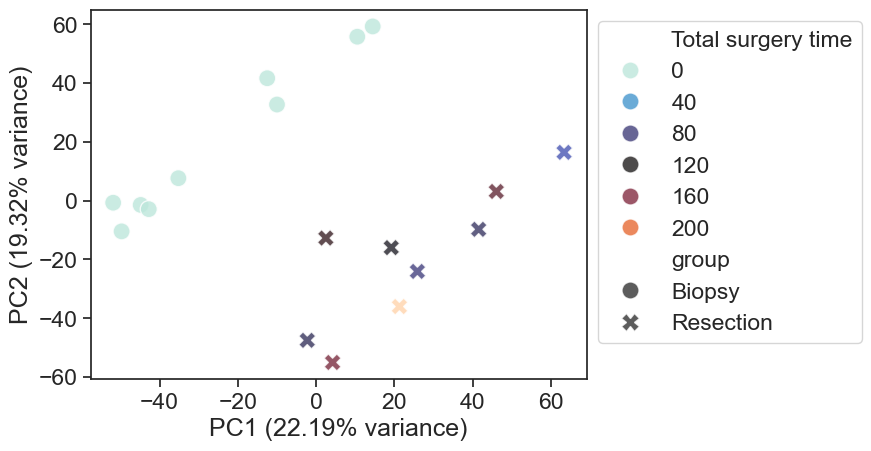

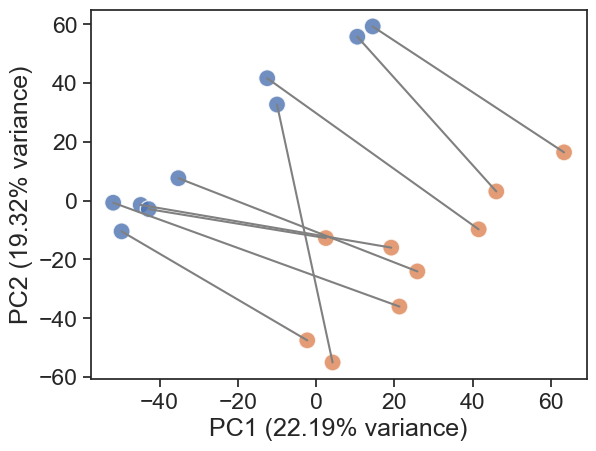

In [57]:
# HCC

# PCA
used_cols = [x for x in df_hcc_imputed.columns if x.startswith('tumor')]
scaled = scaler.fit_transform(df_hcc_imputed.loc[:,used_cols].T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=['PC1', 'PC2'])
df_pca['group'] = metadata_hcc.Sample_type
df_pca['sex'] = metadata_hcc.Sex
df_pca['patient_id'] = metadata_hcc.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_hcc['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_hcc['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_sex.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_timeBvR.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_hcc_surgerytime.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_hcc_pat.pdf', bbox_inches='tight', dpi=300)

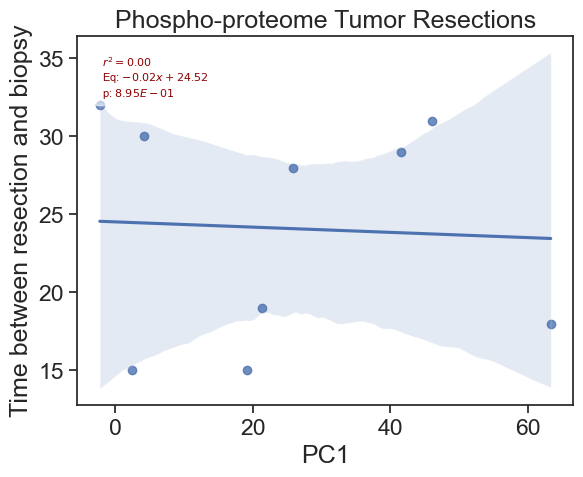

In [58]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Tumor Resections')


plt.savefig('figures/corr_pc1_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

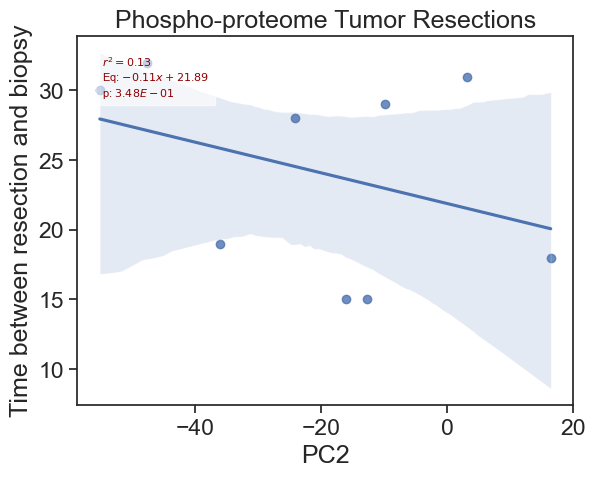

In [59]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Phospho-proteome Tumor Resections')


plt.savefig('figures/corr_pc2_time_b_to_r_tumor.pdf', dpi=300, bbox_inches='tight')

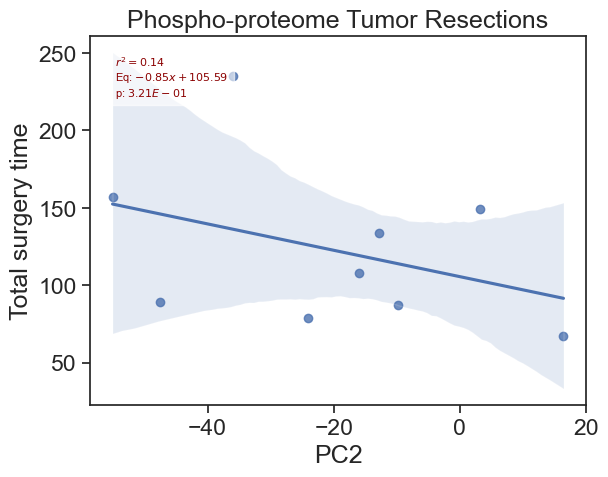

In [60]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Tumor Resections')

plt.savefig('figures/corr_pc2_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

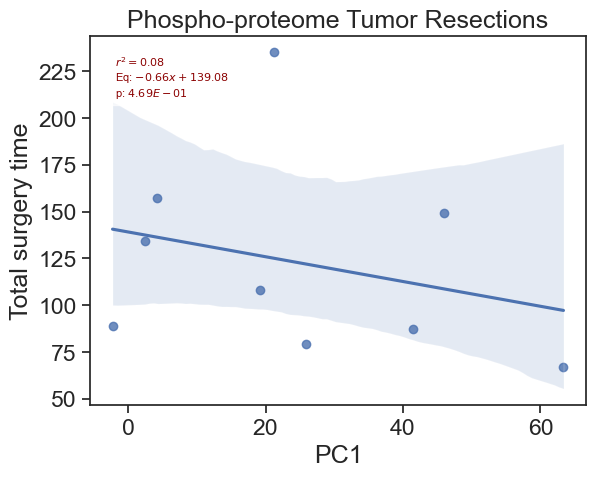

In [61]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Phospho-proteome Tumor Resections')

plt.savefig('figures/corr_pc1_time_surgery_tumor.pdf', dpi=300, bbox_inches='tight')

# Ttest

In [62]:
# Helper functions for calculating p-values, adjusted p-values and fold-changes
from scipy import stats

def students_ttest(df, group_cols, control_cols, index_col=None,
                   group_name="group", control_name="control",
                   paired=False, pairing=None):
    """
    Perform Student's t-test (paired or unpaired) between two groups of samples.

    Parameters:
    - df : pandas.DataFrame
        Features as rows, samples as columns.
    - group_cols : list of str
        Column names of the treatment group.
    - control_cols : list of str
        Column names of the control group.
    - index_col : str or None
        If provided, column to set as index in the result.
    - group_name : str
        Label for the group (used in output column names).
    - control_name : str
        Label for the control (used in output column names).
    - paired : bool
        If True, perform paired t-test (requires `pairing`).
    - pairing : pd.Series or None
        Required if `paired=True`. Index = sample names (columns), values = pairing IDs.

    Returns:
    - df_result : pandas.DataFrame
        Contains t-statistics, p-values, adjusted p-values, and fold changes.
    """
    df_ = df.copy()

    if paired:
        if pairing is None:
            raise ValueError("Pairing metadata must be provided for paired t-test.")
        # Map pair IDs to columns for each group
        group_pairs = pairing.loc[group_cols]
        control_pairs = pairing.loc[control_cols]

        # Find common pair IDs between group and control
        common_pairs = group_pairs[group_pairs.isin(control_pairs.values)].unique()
        if len(common_pairs) == 0:
            raise ValueError("No matching pair IDs found between group and control.")

        # Align columns based on common pair IDs
        group_aligned = [col for col in group_cols if pairing[col] in common_pairs]
        control_aligned = [col for col in control_cols if pairing[col] in common_pairs]
        
        # Map from pair ID to column
        group_map = {pairing[col]: col for col in group_aligned}
        control_map = {pairing[col]: col for col in control_aligned}
        shared_pairs = sorted(set(group_map.keys()) & set(control_map.keys()))

        group_cols_final = [group_map[p] for p in shared_pairs]
        control_cols_final = [control_map[p] for p in shared_pairs]

        if len(group_cols_final) != len(control_cols_final):
            raise ValueError("Aligned paired samples are not the same length.")

        # Paired t-test
        tstats, pvals = stats.ttest_rel(
            df_[group_cols_final].values,
            df_[control_cols_final].values,
            axis=1,
            nan_policy='propagate'
        )
        fold_change = df_[group_cols_final].mean(axis=1) - df_[control_cols_final].mean(axis=1)
    else:
        # Unpaired t-test
        ttest_result = stats.ttest_ind(
            df_[group_cols],
            df_[control_cols],
            axis=1,
            nan_policy='propagate'
        )
        tstats = ttest_result.statistic
        pvals = ttest_result.pvalue
        fold_change = df_[group_cols].mean(axis=1) - df_[control_cols].mean(axis=1)

    label = f"{group_name}vs{control_name}"
    stats_col = f"{label}_tstat"
    pval_col = f"{label}_pval"
    adj_pval_col = f"{label}_adj_pval"
    fc_col = f"{label}_fc"

    # Build result table
    df_[stats_col] = tstats
    df_[pval_col] = pvals
    df_[fc_col] = fold_change

    # Multiple testing correction (Benjamini-Hochberg)
    df_ = df_.sort_values(pval_col).reset_index(names='ID')
    n = df_.shape[0]
    ranks = np.arange(1, n + 1)
    bh_adj = df_[pval_col] * n / ranks
    df_[adj_pval_col] = np.minimum.accumulate(bh_adj[::-1])[::-1].clip(upper=1.0)


    df_.index = df_.ID  # preserve original

    return df_


def power_to_transform(x):
    return 10 ** -x
def neg_log10(x):
    return np.log10(1/x)

In [63]:
res = students_ttest(
    df=df_liver_imputed,
    group_cols=metadata_liver[metadata_liver.Sample_type == 'Resection'].index,
    control_cols=metadata_liver[metadata_liver.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_liver.patient_id,
)


In [64]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [65]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MAP4_S928,MAP4_S928,21.407136,21.480015,22.194438,20.525559,20.972842,21.471978,20.517416,21.933025,20.831711,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,24.626638,25.195925,26.043545,24.561665,25.375305,23.573692,25.519417,25.740126,24.247301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.163150,1.350637e-07,3.727722,0.000781,6.869461
RPL29_S158,RPL29_S158,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.117594,14.888734,15.085470,15.893738,15.139720,16.944170,14.786229,13.968487,14.569589,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-14.683938,4.544667e-07,-3.607532,0.000975,6.342498
MKNK1_T385,MKNK1_T385,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.065733,12.126143,14.898343,13.765348,13.918060,13.627864,15.125259,13.180946,14.181851,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-14.409871,5.257918e-07,-4.996886,0.000975,6.279186
GOLGA2_S273,GOLGA2_S273,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.303403,15.582542,15.482637,14.866603,14.759390,15.362386,14.632223,15.823255,15.560760,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,-13.854511,7.122392e-07,-3.609813,0.000975,6.147374
NCKAP5L_S1194,NCKAP5L_S1194,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.174857,15.694391,16.876793,16.283065,17.600471,16.534341,16.492017,16.154345,16.303522,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,-13.554121,8.432992e-07,-2.305301,0.000975,6.074018


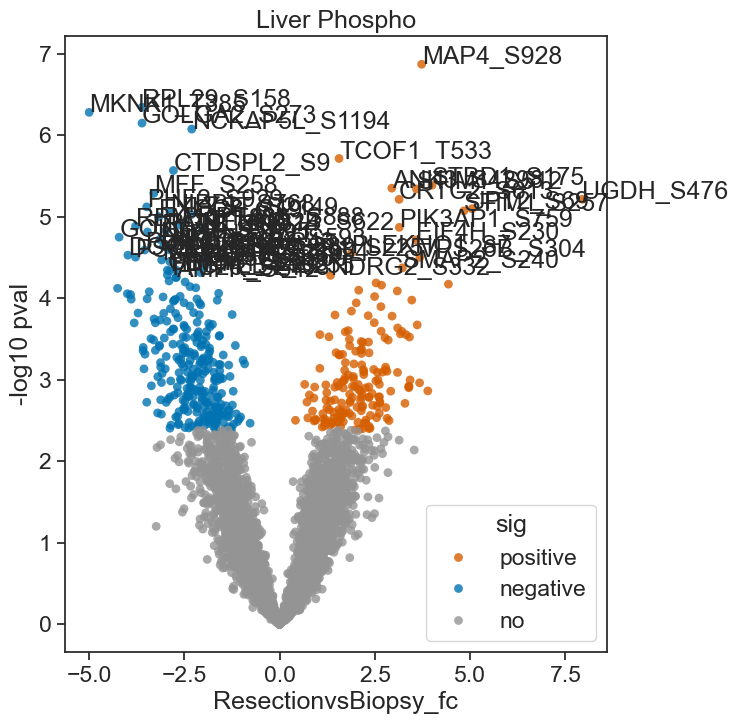

In [66]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)
                

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('Liver Phospho')
#plt.show()
plt.savefig('Volcano_proteomics_liver_output.pdf', bbox_inches='tight', dpi=300)

In [67]:
df_ttest_.to_csv(f'phospho_ttest_Liver_{today}.csv')

In [68]:
df_liver_sig = most_sig[most_sig.sig != 'no'].copy()
df_liver_sig.shape

(479, 43)

In [69]:
# HCC

res = students_ttest(
    df=df_hcc_imputed,
    group_cols=metadata_hcc[metadata_hcc.Sample_type == 'Resection'].index,
    control_cols=metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_hcc.patient_id,
)

In [70]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [71]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_U,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_U,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_U,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RBM7_S136,RBM7_S136,16.865715,14.426612,14.734572,14.419401,16.399552,16.645127,13.053086,16.681470,16.701978,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,21.104632,19.414186,20.131407,19.445407,21.116496,19.479234,18.236110,20.676522,20.542155,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.770457,1.029216e-07,4.468737,0.000262,6.987493
DMXL1_S1896,DMXL1_S1896,19.333867,18.177003,18.484161,17.999423,19.054616,19.018401,18.235575,19.567059,19.142322,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.826159,15.131801,15.819328,15.060154,16.585014,15.703201,15.897338,15.920902,16.716455,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,-17.751791,1.037712e-07,-2.928008,0.000262,6.983923
DYNC1LI1_S516,DYNC1LI1_S516,19.333867,18.177003,18.484161,17.999423,19.054616,19.018401,18.235575,19.567059,19.142322,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,21.601131,21.102891,21.309386,21.373607,21.774077,20.805169,21.162681,21.822179,21.794981,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,16.544933,1.798247e-07,2.637075,0.000275,6.745151
SORBS2_S1017,SORBS2_S1017,19.333867,18.177003,18.484161,17.999423,19.054616,19.018401,18.235575,19.567059,19.142322,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24.581925,21.486419,22.021192,21.602472,23.534120,22.588294,21.757644,23.268280,24.253093,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16.142798,2.178211e-07,4.009001,0.000275,6.661900
ACIN1_T414,ACIN1_T414,17.144182,15.384277,16.477839,14.815813,16.811325,17.055365,15.552715,16.830367,16.166224,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,19.298987,17.709826,18.659226,16.790935,19.237376,18.346501,18.132730,18.134751,18.390968,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,15.509933,2.972871e-07,2.051466,0.000282,6.526824


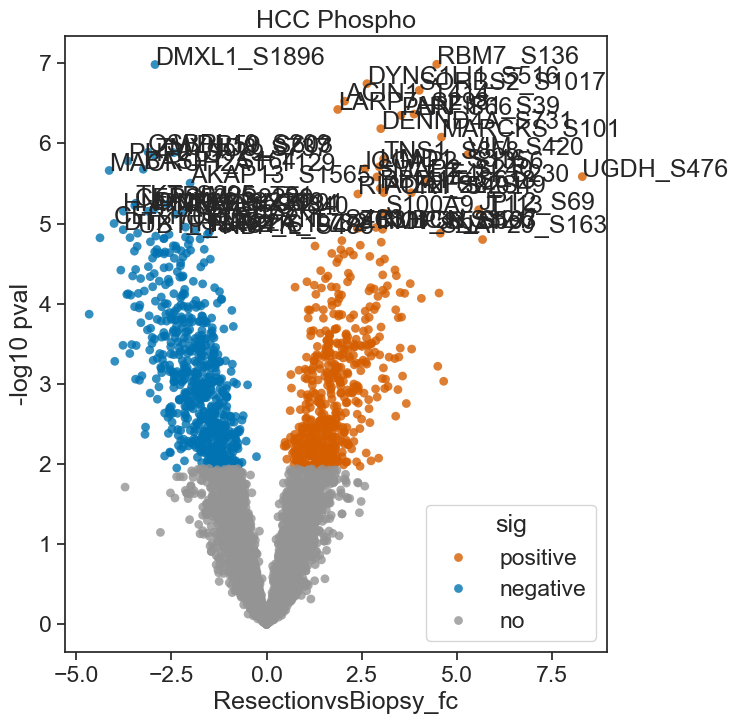

In [72]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('HCC Phospho')
#plt.show()
plt.savefig('Volcano_proteomics_hcc_output.pdf', bbox_inches='tight', dpi=300)

In [73]:
df_ttest_.to_csv(f'phospho_ttest_hcc_{today}.csv')

In [70]:
df_hcc_sig = most_sig[most_sig.sig != 'no'].copy()
df_hcc_sig.shape

(1147, 43)

In [71]:
df_heatmap_l = df_liver_sig.iloc[:,-6:].copy()
df_heatmap_h = df_hcc_sig.iloc[:,-6:].copy()

df_heatmap_l = df_heatmap_l.drop(['ResectionvsBiopsy_tstat', 'ResectionvsBiopsy_pval',
                                  'ResectionvsBiopsy_adj_pval'], axis=1)

df_heatmap_h = df_heatmap_h.drop(['ResectionvsBiopsy_tstat', 'ResectionvsBiopsy_pval',
                                  'ResectionvsBiopsy_adj_pval'], axis=1)

df_heatmap = df_heatmap_l.merge(df_heatmap_h, left_index=True, right_index=True, suffixes=('_liver', '_hcc'), how='outer')
#df_heatmap.index = df_heatmap.Gene_liver
df_heatmap.head()

,ResectionvsBiopsy_fc_liver,-log10 pval_liver,sig_liver,ResectionvsBiopsy_fc_hcc,-log10 pval_hcc,sig_hcc
ID,,,,,,
AAK1_S624,NaN,NaN,NaN,1.339144,2.044966,positive
AAK1_T620,NaN,NaN,NaN,1.678567,2.557327,positive
ABCB11_S686,NaN,NaN,NaN,1.295878,4.116322,positive
ABCB11_S694,NaN,NaN,NaN,1.580775,3.143818,positive
ABCF1_S166,NaN,NaN,NaN,-1.553106,2.374474,negative


In [72]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

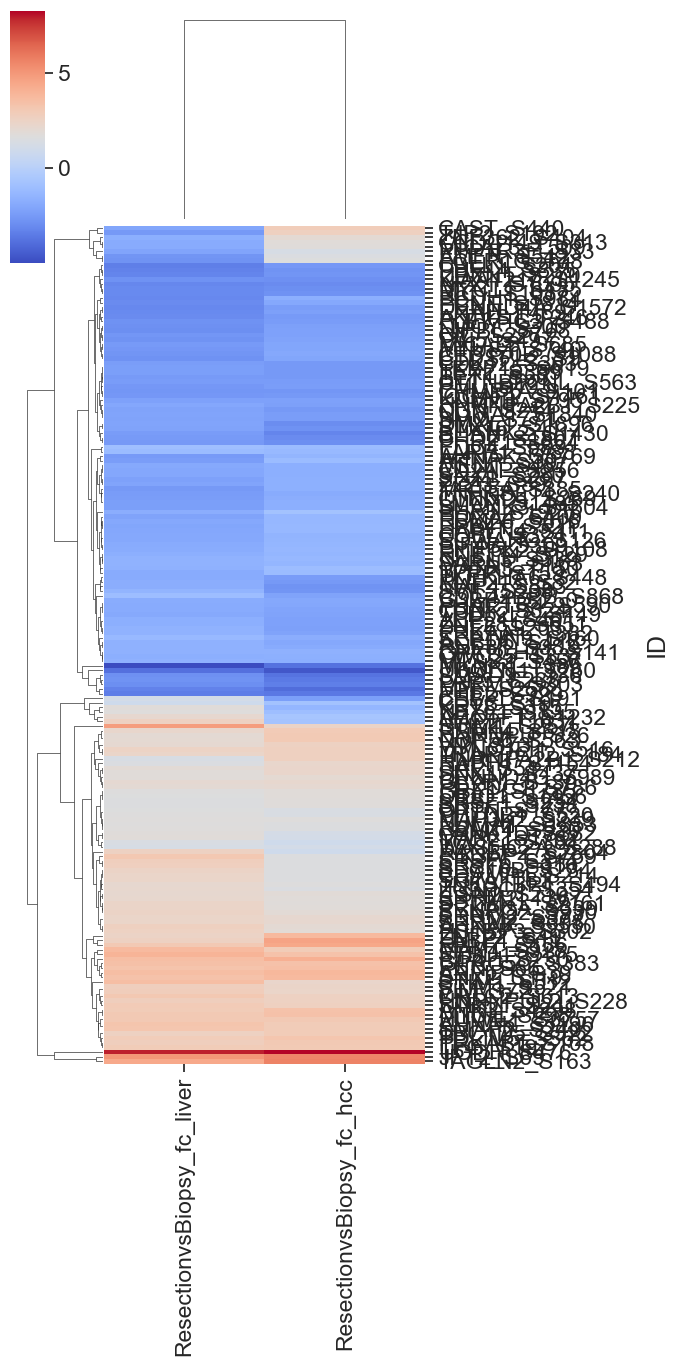

In [73]:
df_heatmap_ = df_heatmap.dropna()
sns.clustermap(df_heatmap_.loc[:,['ResectionvsBiopsy_fc_liver', 'ResectionvsBiopsy_fc_hcc']],
           cmap='coolwarm', yticklabels=True, figsize=(7,14))

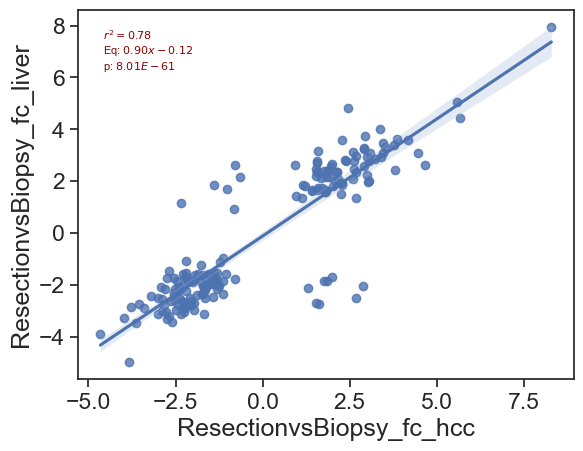

In [74]:
sns.regplot(df_heatmap_, x='ResectionvsBiopsy_fc_hcc', y='ResectionvsBiopsy_fc_liver' )

r2(df_heatmap.ResectionvsBiopsy_fc_hcc, df_heatmap.ResectionvsBiopsy_fc_liver)
plt.savefig('figures/Correlations_phospho.pdf', dpi=300, bbox_inches='tight')

In [75]:
df_heatmap_['diff'] = abs(df_heatmap_.ResectionvsBiopsy_fc_liver) - abs(df_heatmap_.ResectionvsBiopsy_fc_hcc)
df_heatmap_ = df_heatmap_.sort_values('diff')

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_19356\1452077984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_heatmap_['diff'] = abs(df_heatmap_.ResectionvsBiopsy_fc_liver) - abs(df_heatmap_.ResectionvsBiopsy_fc_hcc)


In [76]:
df_heatmap_[(df_heatmap_.ResectionvsBiopsy_fc_hcc > 1) &(df_heatmap_.ResectionvsBiopsy_fc_liver < 0)]

,ResectionvsBiopsy_fc_liver,-log10 pval_liver,sig_liver,ResectionvsBiopsy_fc_hcc,-log10 pval_hcc,sig_hcc,diff
ID,,,,,,,
CAST_S440,-2.038947,2.775687,negative,2.871383,3.538526,positive,-0.832435
ZNF362_S404,-1.686536,2.664130,negative,1.980347,2.279478,positive,-0.293811
TJP2_S192,-2.514260,3.158271,negative,2.678207,3.395047,positive,-0.163947
CCDC149_S313,-1.861021,3.689009,negative,1.845528,3.216352,positive,0.015494
MICAL3_T509,-1.850945,3.253893,negative,1.761680,3.072277,positive,0.089265
PPP1R3E_S33,-2.135629,3.086936,negative,1.298724,1.949258,positive,0.836905
FCER1G_T78,-2.728140,3.811959,negative,1.629451,2.563019,positive,1.098689
AMFR_S542,-2.707889,4.258724,negative,1.529272,2.230995,positive,1.178616


In [77]:
df_heatmap_[(df_heatmap_.ResectionvsBiopsy_fc_hcc < 0) &(df_heatmap_.ResectionvsBiopsy_fc_liver > 0)]

,ResectionvsBiopsy_fc_liver,-log10 pval_liver,sig_liver,ResectionvsBiopsy_fc_hcc,-log10 pval_hcc,sig_hcc,diff
ID,,,,,,,
CEBPD_S191,1.135481,2.583635,positive,-2.334816,2.429519,negative,-1.199335
CDV3_S197,0.921004,2.909968,positive,-0.808420,2.039133,negative,0.112584
KRT8_S315,1.844930,2.720843,positive,-1.403716,2.418360,negative,0.441214
NFXL1_S835,1.706713,3.115944,positive,-1.035479,2.044479,negative,0.671234
AHCTF1_S1232,2.140611,2.785746,positive,-0.644430,2.546938,negative,1.496181
MAP2_T1631,2.620248,2.789283,positive,-0.779244,2.220697,negative,1.841004


In [78]:
df_heatmap_[((df_heatmap_.ResectionvsBiopsy_fc_hcc > 1) & (df_heatmap_.ResectionvsBiopsy_fc_liver < 0)) |\
                     ((df_heatmap_.ResectionvsBiopsy_fc_hcc < 0) & (df_heatmap_.ResectionvsBiopsy_fc_liver > 0))].to_csv('opposite_directionality.csv')

In [79]:
df_heatmap_.to_csv('Phospho_sig_sites_051225.csv')

In [80]:
def gct_format(df, title, p_val, fc_col):
    # Turn p val into log10 and negative for negative fold change sites (input for PTMsigDB)
    df_ = df.copy()
    df_ = df_.apply(lambda x: abs(np.log10(x)) if x.name in p_val else x)
    df_[p_val] = np.where((df_[fc_col] > 0), df_[p_val], (df_[p_val] - 2*(df_[p_val].abs())))
    df_ = df_.loc[:,['id.uniprot', p_val]]

    # Write GCT format file descriptives
    with open(f'gct_files/{title}.gct', 'w') as f:
        f.write('#1.2 \n')
        f.write(f'{len(df)}\t1 \n')
    # Dump dataframe to GCT file
    df_.to_csv(f'gct_files/{title}.gct', mode='a', sep='\t',index=False)

In [81]:
df_liver_sig

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MAP4_S928,MAP4_S928,21.407136,21.480015,22.194438,20.525559,20.972842,21.471978,20.517416,21.933025,20.831711,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,24.626638,25.195925,26.043545,24.561665,25.375305,23.573692,25.519417,25.740126,24.247301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.163150,1.350637e-07,3.727722,0.000781,6.869461,positive
RPL29_S158,RPL29_S158,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.117594,14.888734,15.085470,15.893738,15.139720,16.944170,14.786229,13.968487,14.569589,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-14.683938,4.544667e-07,-3.607532,0.000975,6.342498,negative
MKNK1_T385,MKNK1_T385,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.065733,12.126143,14.898343,13.765348,13.918060,13.627864,15.125259,13.180946,14.181851,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-14.409871,5.257918e-07,-4.996886,0.000975,6.279186,negative
GOLGA2_S273,GOLGA2_S273,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.303403,15.582542,15.482637,14.866603,14.759390,15.362386,14.632223,15.823255,15.560760,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,-13.854511,7.122392e-07,-3.609813,0.000975,6.147374,negative
NCKAP5L_S1194,NCKAP5L_S1194,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.174857,15.694391,16.876793,16.283065,17.600471,16.534341,16.492017,16.154345,16.303522,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,-13.554121,8.432992e-07,-2.305301,0.000975,6.074018,negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDC42EP4_S140,CDC42EP4_S140,16.754003,15.220964,14.209510,15.950012,17.248482,16.677702,16.533946,16.402816,18.127225,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,18.731475,19.216097,19.031106,18.563114,17.671306,18.718907,18.002941,18.385332,17.660699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.985618,4.029918e-03,2.095147,0.049038,2.394704,positive
TCEA3_S140,TCEA3_S140,22.097883,22.477446,21.342800,20.376462,24.728561,23.122807,22.884934,22.227027,22.030979,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,20.317629,20.176066,19.878326,20.099267,20.330719,21.026149,23.324710,20.315706,20.860564,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,-3.982720,4.046277e-03,-1.662196,0.049072,2.392944,negative
AKAP13_S1507,AKAP13_S1507,18.477538,18.849234,17.654262,17.204701,17.992026,19.018899,18.051218,18.484534,17.535116,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,16.471067,16.950100,14.669206,17.597387,16.445181,17.448163,16.763819,18.024285,15.973769,1.0,1.0,0.0,1.0,1.0,1.0,

In [82]:
df_raw = df.copy()
df_raw.index = df_raw.site_id
df_raw = df_raw.Protein
df_raw

site_id
CCDC187_S478     A0A096LP49
POLGARF_S38      A0A3B3IS91
RAMACL_S36       A0A3B3IU46
SLC12A8_S665         A0AV02
E2F8_T58             A0AVK6
                    ...    
MORC2_S739           Q9Y6X9
MORC2_S743           Q9Y6X9
IVNS1ABP_S338        Q9Y6Y0
SEC23IP_S737         Q9Y6Y8
SEC23IP_S926         Q9Y6Y8
Name: Protein, Length: 11444, dtype: object

In [83]:
df_liver_sig['Protein'] = df_liver_sig.index.map(df_raw)
df_liver_sig

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_U,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_U,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_U,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_U,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig,Protein
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
MAP4_S928,MAP4_S928,21.407136,21.480015,22.194438,20.525559,20.972842,21.471978,20.517416,21.933025,20.831711,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,24.626638,25.195925,26.043545,24.561665,25.375305,23.573692,25.519417,25.740126,24.247301,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.163150,1.350637e-07,3.727722,0.000781,6.869461,positive,P27816
RPL29_S158,RPL29_S158,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.117594,14.888734,15.085470,15.893738,15.139720,16.944170,14.786229,13.968487,14.569589,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,-14.683938,4.544667e-07,-3.607532,0.000975,6.342498,negative,P47914
MKNK1_T385,MKNK1_T385,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,13.065733,12.126143,14.898343,13.765348,13.918060,13.627864,15.125259,13.180946,14.181851,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,-14.409871,5.257918e-07,-4.996886,0.000975,6.279186,negative,Q9BUB5
GOLGA2_S273,GOLGA2_S273,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,14.303403,15.582542,15.482637,14.866603,14.759390,15.362386,14.632223,15.823255,15.560760,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,-13.854511,7.122392e-07,-3.609813,0.000975,6.147374,negative,Q08379
NCKAP5L_S1194,NCKAP5L_S1194,18.777912,18.172117,18.543508,18.274619,19.771674,19.471492,18.324646,18.497124,19.028425,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,16.174857,15.694391,16.876793,16.283065,17.600471,16.534341,16.492017,16.154345,16.303522,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,-13.554121,8.432992e-07,-2.305301,0.000975,6.074018,negative,Q9HCH0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CDC42EP4_S140,CDC42EP4_S140,16.754003,15.220964,14.209510,15.950012,17.248482,16.677702,16.533946,16.402816,18.127225,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,18.731475,19.216097,19.031106,18.563114,17.671306,18.718907,18.002941,18.385332,17.660699,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.985618,4.029918e-03,2.095147,0.049038,2.394704,positive,Q9H3Q1
TCEA3_S140,TCEA3_S140,22.097883,22.477446,21.342800,20.376462,24.728561,23.122807,22.884934,22.227027,22.030979,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,20.317629,20.176066,19.878326,20.099267,20.330719,21.026149,23.324710,20.315706,20.860564,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,-3.982720,4.046277e-03,-1.662196,0.049072,2.392944,negative,O75764
AKAP13_S1507,AKAP13_S1507,18.477538,18.849234,17.654262,17.204701,17.992026,19.018899,18.051218,18.484534,17.535116,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,16.471067,16.950100,14.669206,17.597387,16.445181,17

In [84]:
df_hcc_sig['Protein'] = df_hcc_sig.index.map(df_raw)
df_hcc_sig

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_U,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_U,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_U,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_U,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig,Protein
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
RBM7_S136,RBM7_S136,16.865715,14.426612,14.734572,14.419401,16.399552,16.645127,13.053086,16.681470,16.701978,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,21.104632,19.414186,20.131407,19.445407,21.116496,19.479234,18.236110,20.676522,20.542155,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17.770457,1.029216e-07,4.468737,0.000262,6.987493,positive,Q9Y580
DMXL1_S1896,DMXL1_S1896,19.333867,18.177003,18.484161,17.999423,19.054616,19.018401,18.235575,19.567059,19.142322,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,15.826159,15.131801,15.819328,15.060154,16.585014,15.703201,15.897338,15.920902,16.716455,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,-17.751791,1.037712e-07,-2.928008,0.000262,6.983923,negative,Q9Y485
DYNC1LI1_S516,DYNC1LI1_S516,19.333867,18.177003,18.484161,17.999423,19.054616,19.018401,18.235575,19.567059,19.142322,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,21.601131,21.102891,21.309386,21.373607,21.774077,20.805169,21.162681,21.822179,21.794981,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,16.544933,1.798247e-07,2.637075,0.000275,6.745151,positive,Q9Y6G9
SORBS2_S1017,SORBS2_S1017,19.333867,18.177003,18.484161,17.999423,19.054616,19.018401,18.235575,19.567059,19.142322,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,24.581925,21.486419,22.021192,21.602472,23.534120,22.588294,21.757644,23.268280,24.253093,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16.142798,2.178211e-07,4.009001,0.000275,6.661900,positive,O94875
ACIN1_T414,ACIN1_T414,17.144182,15.384277,16.477839,14.815813,16.811325,17.055365,15.552715,16.830367,16.166224,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,19.298987,17.709826,18.659226,16.790935,19.237376,18.346501,18.132730,18.134751,18.390968,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,15.509933,2.972871e-07,2.051466,0.000282,6.526824,positive,Q9UKV3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RSL1D1_S361,RSL1D1_S361,19.819447,18.773423,17.790743,18.275938,18.662069,18.377858,18.945590,18.808914,20.539990,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,20.958100,20.712989,21.055182,20.051767,21.458098,20.706450,17.484398,22.000755,20.797867,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.281833,1.115723e-02,1.692404,0.049315,1.952444,positive,O76021
PDZK1_T356,PDZK1_T356,18.357553,18.091253,17.579230,17.372712,17.862195,17.436582,17.076440,18.706377,19.391712,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,20.145955,20.116364,19.347954,18.103559,20.073224,18.589991,19.517563,19.302252,18.268460,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,3.281509,1.116263e-02,1.287919,0.049315,1.952233,positive,Q5T2W1
DMTN_S26,DMTN_S26,18.689937,17.170209,18.809762,17.430378,18.784453,18.070997,18.307525,19.383242,20.889104,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,21.009331,18.247765,20.185606,18.457385,18.697682,19.770088,18.284002,21.137680,20.321576,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,3.278314,1.121602e-02,0.952834,0.049507,1.950161,positive,Q08495


In [85]:
# GCT format for PTMsigDB
# Save GCT 1.2 format for PTMsigDB
df_ttest_subset = df_liver_sig.copy()
df_ttest_subset['id.uniprot'] = df_ttest_subset.loc[:,'Protein'] \
                            .str.cat(df_ttest_subset.Gene.str.split('_').str[-1], sep=';') + '-p'
gct_columns = ['id.uniprot']
q_val = 'ResectionvsBiopsy_adj_pval'
fc_col = 'ResectionvsBiopsy_fc'
gct_columns.append(q_val)
gct_columns.append(fc_col)
to_gct_df = df_ttest_subset.loc[:,gct_columns]
#to_gct_df
gct_format(to_gct_df, 'liver', q_val, fc_col)

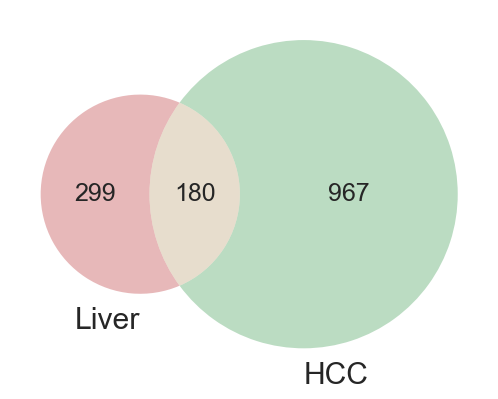

In [86]:
from matplotlib_venn import venn2

set1 = set(df_liver_sig.Gene)
set2 = set(df_hcc_sig.Gene)

venn2([set1, set2], ('Liver', 'HCC'))

plt.savefig('figures/Venn_sig_degs_liver_vs_hcc.pdf', dpi=300, bbox_inches='tight')